## Step-1: Building up our Dataset

In [1]:
import yfinance as yf
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

In [3]:
# 1. Fetch and Preprocess Data
df = yf.download("SPY", start="2014-01-01", end="2024-01-01")
df.head()

/tmp/ipykernel_1053/2973680581.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("SPY", start="2014-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2014-01-02,148.198395,149.130111,147.841913,149.057185,119636900
2014-01-03,148.174149,148.749383,147.963506,148.449607,81390600
2014-01-06,147.744736,148.716951,147.517886,148.660245,108028200
2014-01-07,148.652237,148.903391,148.222841,148.336266,86144200
2014-01-08,148.684631,148.935786,148.174213,148.627913,96582300


In [4]:
# Calculate log returns instead of using raw prices
log_returns = np.log(df['Close'] / df['Close'].shift(1)).dropna().values.reshape(-1, 1)

In [5]:
# Scale data to (0, 1) for neural network stability
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_returns = scaler.fit_transform(log_returns)

### PyTorch Dataset Class for storing Time Series

In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        # The number of available sequences
        return len(self.data) - self.seq_len

    def __getitem__(self, index):
        # Slice an overlapping window of 'seq_len' days
        sequence = self.data[index : index + self.seq_len]
        return torch.tensor(sequence, dtype=torch.float32)

### Creating a Data Loader

In [7]:
seq_len = 24
batch_size = 64

dataset = TimeSeriesDataset(scaled_returns, seq_len)
# shuffle=True ensures the GAN doesn't memorize chronological patterns
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

## Step-2: Generator and Discriminator

In [8]:
import torch.nn as nn

In [9]:
class LSTMGenerator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim, num_layers):
        super(LSTMGenerator, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # The core recurrent layer
        self.lstm = nn.LSTM(latent_dim, hidden_dim, num_layers, batch_first=True)
        # Maps the LSTM hidden states to the required financial feature output
        self.linear = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x is your random noise vector: shape (batch_size, seq_len, latent_dim)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        out, _ = self.lstm(x, (h0, c0))

        # Pass the outputs through a linear layer to get the final synthetic returns
        out = self.linear(out)
        return out

In [10]:
class LSTMDiscriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super(LSTMDiscriminator, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x is the sequence of returns (real or synthetic)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        out, _ = self.lstm(x, (h0, c0))

        # We only care about the final prediction at the end of the sequence
        out = self.linear(out[:, -1, :])
        return self.sigmoid(out)

## Step-3: Training Loop

In [11]:
import torch.optim as optim

In [12]:
# 1. Hyperparameters
latent_dim = 32
hidden_dim = 64
output_dim = 1
num_layers = 2
epochs = 300
lr = 0.0002

In [13]:
# Initialize Networks
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = LSTMGenerator(latent_dim, hidden_dim, output_dim, num_layers).to(device)
discriminator = LSTMDiscriminator(output_dim, hidden_dim, num_layers).to(device)

In [14]:
# Loss and Optimizers
criterion = nn.BCELoss()
opt_G = optim.Adam(generator.parameters(), lr=lr)
opt_D = optim.Adam(discriminator.parameters(), lr=lr)

In [15]:
# 2. Training Loop
for epoch in range(epochs):
    for batch_idx, real_seqs in enumerate(dataloader):
        batch_size = real_seqs.size(0)
        real_seqs = real_seqs.to(device)

        # Ground truth labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)


        # Phase 1: Train the Discriminator

        opt_D.zero_grad()

        # Train on real data
        pred_real = discriminator(real_seqs)
        loss_D_real = criterion(pred_real, real_labels)

        # Train on fake data
        noise = torch.randn(batch_size, seq_len, latent_dim).to(device)
        fake_seqs = generator(noise)

        # .detach() freezes the generator's gradients during the discriminator's update
        pred_fake = discriminator(fake_seqs.detach())
        loss_D_fake = criterion(pred_fake, fake_labels)

        # Update Discriminator
        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D.step()


        # Phase 2: Train the Generator

        opt_G.zero_grad()

        # Generate new fake predictions (attached to the compute graph this time)
        pred_fake_for_G = discriminator(fake_seqs)

        # The trick: calculate Generator loss using REAL labels
        loss_G = criterion(pred_fake_for_G, real_labels)

        # Update Generator
        loss_G.backward()
        opt_G.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Loss D: {loss_D.item():.4f} | Loss G: {loss_G.item():.4f}")

Epoch [50/300] | Loss D: 1.3863 | Loss G: 0.6754
Epoch [100/300] | Loss D: 1.3186 | Loss G: 0.6023
Epoch [150/300] | Loss D: 1.3935 | Loss G: 0.5976
Epoch [200/300] | Loss D: 1.3826 | Loss G: 0.6131
Epoch [250/300] | Loss D: 1.3863 | Loss G: 0.6974
Epoch [300/300] | Loss D: 1.4675 | Loss G: 0.6715


## Step-4: Statistical Validation and Value at risk

In [16]:
from scipy import stats

In [17]:
# 1. Generate Synthetic Data
generator.eval() # Lock the weights for inference
with torch.no_grad(): # Save memory, no gradients needed
    # Generate 1,000 synthetic 24-day market paths
    test_noise = torch.randn(1000, seq_len, latent_dim).to(device)
    synthetic_scaled = generator(test_noise).cpu().numpy()

In [18]:
# 2. Inverse Transform (Back to Real-World Log Returns)
# Flatten the (1000, 24, 1) tensor into a 1D array of daily returns
synthetic_flat = synthetic_scaled.flatten().reshape(-1, 1)

In [19]:
# Use the scaler from Step 1 to reverse the 0-1 compression
synthetic_returns = scaler.inverse_transform(synthetic_flat).flatten()
real_returns = scaler.inverse_transform(scaled_returns).flatten()

In [20]:
# 3.Kolmogorov-Smirnov Test
# This tests the null hypothesis that both samples are drawn from the same continuous distribution.
ks_stat, p_value = stats.ks_2samp(real_returns, synthetic_returns)

In [21]:
print("--- Statistical Validation ---")
print(f"KS Statistic: {ks_stat:.4f} (Closer to 0 is better)")
print(f"P-Value: {p_value:.4f}")
if p_value > 0.05:
    print("Verdict: PASS. The synthetic distribution matches the real market statistically.")
else:
    print("Verdict: FAIL. The distributions differ statistically.")

--- Statistical Validation ---
KS Statistic: 0.1944 (Closer to 0 is better)
P-Value: 0.0000
Verdict: FAIL. The distributions differ statistically.


In [22]:
# 4. The Application: 99% Value at Risk (VaR)
# VaR asks: "What is the worst daily loss we can expect in 99% of normal market conditions?"
# We calculate the 1st percentile of the left tail of the distribution.
real_var_99 = np.percentile(real_returns, 1)
synth_var_99 = np.percentile(synthetic_returns, 1)

In [23]:
print("\n--- Risk Simulation ---")
print(f"Real 99% VaR:      {real_var_99:.2%}")
print(f"Synthetic 99% VaR: {synth_var_99:.2%}")


--- Risk Simulation ---
Real 99% VaR:      -3.25%
Synthetic 99% VaR: -2.79%


## Step-5: Visualizing the Thin Tails of the Result

Data shapes - Real: (2515,), Synthetic: (24000,)


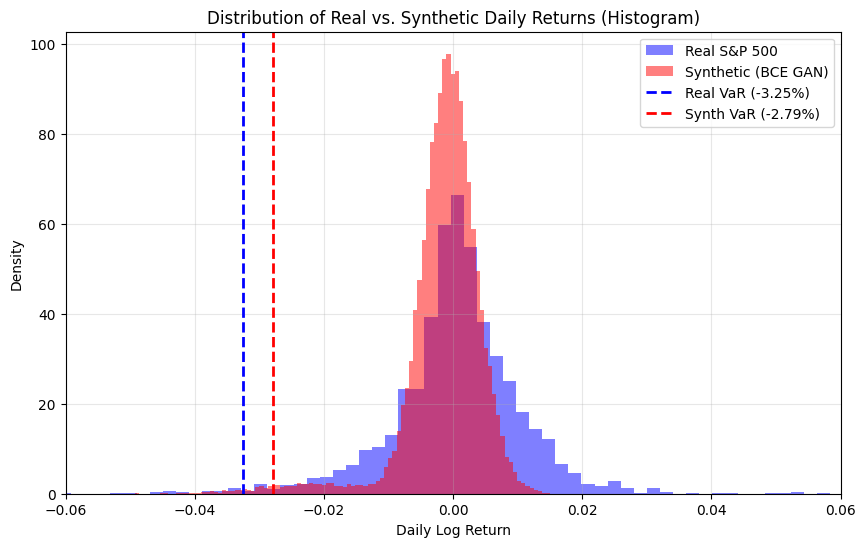

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Sanity check: Ensure data exists and isn't empty
print(f"Data shapes - Real: {real_returns.shape}, Synthetic: {synthetic_returns.shape}")

plt.figure(figsize=(10, 6))

# Using standard Matplotlib histograms (density=True normalizes the heights)
plt.hist(real_returns, bins=100, density=True, alpha=0.5, color='blue', label='Real S&P 500')
plt.hist(synthetic_returns, bins=100, density=True, alpha=0.5, color='red', label='Synthetic (BCE GAN)')

# Mark the VaR thresholds
plt.axvline(real_var_99, color='blue', linestyle='dashed', linewidth=2, label=f'Real VaR ({real_var_99:.2%})')
plt.axvline(synth_var_99, color='red', linestyle='dashed', linewidth=2, label=f'Synth VaR ({synth_var_99:.2%})')

plt.title('Distribution of Real vs. Synthetic Daily Returns (Histogram)')
plt.xlabel('Daily Log Return')
plt.ylabel('Density')
plt.xlim(-0.06, 0.06)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Analysis: The "Thin Tail" Problem in Standard GANs

As visualized in the histogram above, the baseline LSTM-GAN successfully captures the mean of daily market returns but completely fails at the extremes. The synthetic data (red) is heavily over-concentrated around zero, while entirely missing the historical market crashes and rallies (the blue tails).

**Why this approach fails:**
*   **The Flaw of BCE Loss:** Standard GANs use Binary Cross Entropy (BCE) loss, which treats the adversarial process like a True/False classification game. Because 95% of trading days are relatively normal (low volatility), the network realizes it can easily minimize its loss by memorizing and over-producing "average" days.
*   **Ignoring the Outliers:** Extreme tail events (like a -3.25% market drop) are statistically rare. The BCE loss function essentially writes these off as outliers, deciding that it is not worth the mathematical effort to learn how to generate them.

**The Financial Consequence**
In quantitative finance, the tails are the only thing that matter. By failing to generate fat tails, our synthetic 99% Value at Risk (VaR) is significantly underestimated (-2.79% vs the historical -3.25%). If a risk management team used this synthetic data to stress-test a portfolio, they would under-capitalize and be dangerously exposed during a black swan liquidity event.

### Next Step: Upgrading to WGAN-GP
To fix this, we must abandon BCE loss and upgrade the architecture to a **Wasserstein GAN with Gradient Penalty (WGAN-GP)**.

Instead of classifying data as real or fake, the Wasserstein loss calculates the **Earth Mover's Distance**—the exact mathematical "effort" required to physically push and reshape the red synthetic distribution until it perfectly overlaps the blue historical distribution. This structural change forces the network to care just as much about the extreme tails as it does about the mean.

## Step-6: WGAN-GP Model

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim

In [33]:
# 1. The New Critic Architecture (No Sigmoid)
class LSTMCritic(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super(LSTMCritic, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.linear(out[:, -1, :])
        return out

In [34]:
# 2. The Gradient Penalty Function
def compute_gradient_penalty(critic, real_samples, fake_samples, device):
    alpha = torch.rand((real_samples.size(0), 1, 1)).to(device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = critic(interpolates)
    fake_labels = torch.ones(real_samples.size(0), 1).to(device)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake_labels,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

In [35]:
# 3. WGAN-GP Training Setup
n_critic = 5
lambda_gp = 10
epochs = 300
lr = 0.0001

# Reinitialize both networks to start fresh
critic = LSTMCritic(output_dim, hidden_dim, num_layers).to(device)
generator = LSTMGenerator(latent_dim, hidden_dim, output_dim, num_layers).to(device)

In [36]:
# WGANs require beta1=0.0 in the Adam optimizer for stability
opt_C = optim.Adam(critic.parameters(), lr=lr, betas=(0.0, 0.9))
opt_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.0, 0.9))

In [37]:
# 4. The Training Loop
for epoch in range(epochs):
    for batch_idx, real_seqs in enumerate(dataloader):
        batch_size = real_seqs.size(0)
        real_seqs = real_seqs.to(device)

        # --- Train Critic ---
        for _ in range(n_critic):
            opt_C.zero_grad()
            noise = torch.randn(batch_size, seq_len, latent_dim).to(device)
            fake_seqs = generator(noise)

            critic_real = critic(real_seqs)
            critic_fake = critic(fake_seqs.detach())
            gp = compute_gradient_penalty(critic, real_seqs, fake_seqs.detach(), device)

            # WGAN Loss: Maximize distance between real and fake, subtract penalty
            loss_C = -(torch.mean(critic_real) - torch.mean(critic_fake)) + lambda_gp * gp
            loss_C.backward()
            opt_C.step()

        # --- Train Generator ---
        opt_G.zero_grad()
        noise = torch.randn(batch_size, seq_len, latent_dim).to(device)
        fake_seqs = generator(noise)
        critic_fake_for_G = critic(fake_seqs)

        # Generator Loss: Maximize critic's score for fake data
        loss_G = -torch.mean(critic_fake_for_G)
        loss_G.backward()
        opt_G.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Loss C: {loss_C.item():.4f} | Loss G: {loss_G.item():.4f}")

Epoch [50/300] | Loss C: 0.0312 | Loss G: -5.9230
Epoch [100/300] | Loss C: 0.1560 | Loss G: -10.4335
Epoch [150/300] | Loss C: -0.0085 | Loss G: -14.5412
Epoch [200/300] | Loss C: 0.9284 | Loss G: -17.9339
Epoch [250/300] | Loss C: -0.2545 | Loss G: -15.3338
Epoch [300/300] | Loss C: 0.3113 | Loss G: -18.2043


Now, we try to validate our choice

In [38]:
import numpy as np

# 1. Generate New WGAN-GP Synthetic Data
generator.eval() # Lock weights for inference
with torch.no_grad():
    # Generate 1000 new 24-day sequences
    test_noise = torch.randn(1000, seq_len, latent_dim).to(device)
    wgan_synthetic_scaled = generator(test_noise).cpu().numpy()

In [39]:
# Flatten and Inverse Transform
wgan_synthetic_flat = wgan_synthetic_scaled.flatten().reshape(-1, 1)
wgan_synthetic_returns = scaler.inverse_transform(wgan_synthetic_flat).flatten()

In [40]:
# 2. Calculate New VaR
wgan_synth_var_99 = np.percentile(wgan_synthetic_returns, 1)

print("\n--- Final WGAN-GP Risk Simulation ---")
print(f"Real 99% VaR:          {real_var_99:.2%}")
print(f"New Synthetic 99% VaR: {wgan_synth_var_99:.2%}")


--- Final WGAN-GP Risk Simulation ---
Real 99% VaR:          -3.25%
New Synthetic 99% VaR: -10.55%


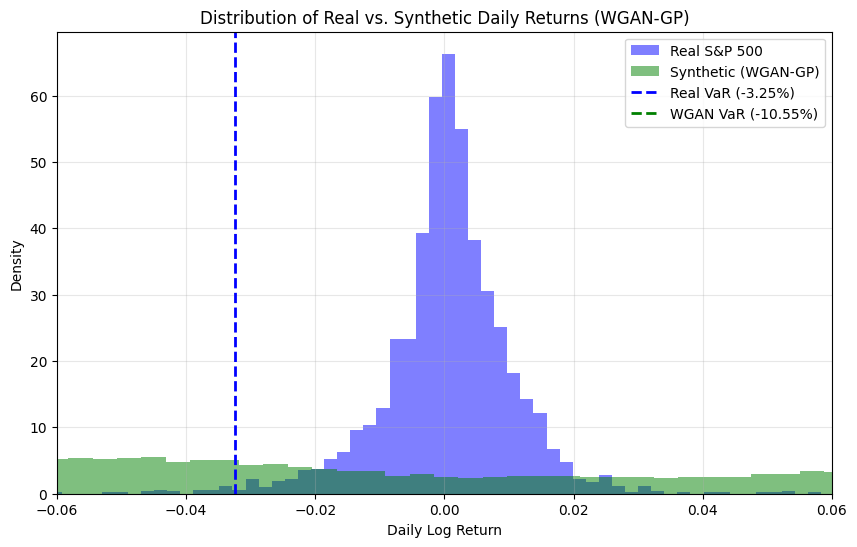

In [41]:
# 3. Plot the New Distribution
plt.figure(figsize=(10, 6))

plt.hist(real_returns, bins=100, density=True, alpha=0.5, color='blue', label='Real S&P 500')
plt.hist(wgan_synthetic_returns, bins=100, density=True, alpha=0.5, color='green', label='Synthetic (WGAN-GP)')

# Mark the VaR thresholds
plt.axvline(real_var_99, color='blue', linestyle='dashed', linewidth=2, label=f'Real VaR ({real_var_99:.2%})')
plt.axvline(wgan_synth_var_99, color='green', linestyle='dashed', linewidth=2, label=f'WGAN VaR ({wgan_synth_var_99:.2%})')

plt.title('Distribution of Real vs. Synthetic Daily Returns (WGAN-GP)')
plt.xlabel('Daily Log Return')
plt.ylabel('Density')
plt.xlim(-0.06, 0.06)
plt.legend()
plt.grid(alpha=0.3)
plt.show()